In [ ]:
# D0. Data Preparation
import nltk
import string
from collections import Counter

nltk.download('brown')
from nltk.corpus import brown

# Load brown's sentences: news
raw_sents = brown.sents(categories='news')
processed_sents = []

# Preprocess tokens: lowercase, remove punctuation-only tokens, keep stopwords
for sent in raw_sents:
  clean_sents = []
  for token in sent:
    token_lower = token.lower()
    if not all(char in string.punctuation for char in token_lower):
      clean_sents.append(token_lower)


# add <bos> at the start, <eos> at the end, <unk> for unknown words.
  final_sent = ['<bos>'] + clean_sents + ['<eos>']
  processed_sents.append(final_sent)

print(f"Total processed sentences: {len(processed_sents)}")
print(f"example sentence: {processed_sents[0]}")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Total processed sentences: 4623
example sentence: ['<bos>', 'the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', '<eos>']


We split data by sentence rather than by token to prevent data leakage. If we split by tokens, fragments of the same sentence could end up in both the training and test sets, artificially boosting the model's performance on the test set.

In [ ]:
# D1. Split Data
total_sents = len(processed_sents)

# 1. Calculate integer indices for 80% and 90%
train_end = int(total_sents * 0.8)
val_end = int(total_sents * 0.9)

# 2. Slice the list to ensure no sentence leakage across splits
train_sents = processed_sents[:train_end]
val_sents = processed_sents[train_end:val_end]
test_sents = processed_sents[val_end:]

# 3. Count total tokens in each split
train_tokens_count = sum(len(s) for s in train_sents)
val_tokens_count = sum(len(s) for s in val_sents)
test_tokens_count = sum(len(s) for s in test_sents)

print("====== Data Split Report ======")
print(f"Train : {len(train_sents)} sentences | {train_tokens_count} tokens")
print(f"Val   : {len(val_sents)} sentences  | {val_tokens_count} tokens")
print(f"Test  : {len(test_sents)} sentences  | {test_tokens_count} tokens")

====== Data Split Report ======
Train : 3698 sentences | 77918 tokens
Val   : 462 sentences  | 10264 tokens
Test  : 463 sentences  | 9656 tokens


In [ ]:
# --- D2. Build Vocabulary (Shared) ---
min_freq = 2

# 1. Flatten the training sentences into a single list of tokens to count frequencies
train_tokens_flat = [token for sent in train_sents for token in sent]
token_counts = Counter(train_tokens_flat)

# 2. Initialize vocabulary with required special tokens
vocab = ['<unk>', '<bos>', '<eos>']

# 3. Add tokens that meet the minimum frequency
for token, count in token_counts.items():
    if count >= min_freq and token not in vocab:
        vocab.append(token)

vocab_size = len(vocab)

# 4. Create the String-to-Integer (stoi) mapping dictionary
stoi = {word: i for i, word in enumerate(vocab)}

print("=== Vocabulary Report ===")
print(f"Chosen min_freq: {min_freq}")
print(f"Final Vocab Size: {vocab_size}")
print("\nTop 20 most frequent tokens in training data:")
for word, count in token_counts.most_common(20):
    print(f" - {word}: {count}")

=== Vocabulary Report ===
Chosen min_freq: 2
Final Vocab Size: 5353

Top 20 most frequent tokens in training data:
 - the: 5072
 - <bos>: 3698
 - <eos>: 3698
 - of: 2321
 - and: 1740
 - a: 1710
 - to: 1649
 - in: 1592
 - for: 787
 - that: 644
 - is: 575
 - was: 566
 - on: 538
 - at: 531
 - he: 509
 - be: 455
 - with: 432
 - by: 398
 - as: 395
 - said: 373


We can see that top 20 most frequent tokens in training data are:
 - the: 5072, `<bos>`: 3698, `<eos>`: 3698, of: 2321, and: 1740, a: 1710, to: 1649 and etc.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- B1 Step 1: Numericalization ---
def numericalize_sentence(sentence, stoi_dict):
    # Fetch the ID for <unk> to use as a default fallback
    unk_id = stoi_dict['<unk>']
    # List comprehension to convert words to integer IDs
    return [stoi_dict.get(token, unk_id) for token in sentence]

# Demonstrate on one example sentence
example_sent = train_sents[0]
num_example = numericalize_sentence(example_sent, stoi)
print("=== Step 1: Numericalization ===")
print(f"Original: {example_sent}")
print(f"Numericalized: {num_example}\n")

# --- B1 Step 2: Build Token Streams ---
train_stream = []
for sent in train_sents:
    train_stream.extend(numericalize_sentence(sent, stoi))

val_stream = []
for sent in val_sents:
    val_stream.extend(numericalize_sentence(sent, stoi))

test_stream = []
for sent in test_sents:
    test_stream.extend(numericalize_sentence(sent, stoi))

print("=== Step 2: Token Streams ===")
print(f"Train stream length: {len(train_stream):,}")
print(f"Val stream length: {len(val_stream):,}")
print(f"Test stream length: {len(test_stream):,}")

=== Step 1: Numericalization ===
Original: ['<bos>', 'the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', '<eos>']
Numericalized: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 2]

=== Step 2: Token Streams ===
Train stream length: 77,918
Val stream length: 10,264
Test stream length: 9,656


In [ ]:
# --- B1 Step 3: PyTorch Dataset ---
class NextTokenStreamDataset(Dataset):
    def __init__(self, stream, seq_len):
        self.stream = stream
        self.seq_len = seq_len

    def __len__(self):
        # The number of valid windows we can extract
        return len(self.stream) - self.seq_len

    def __getitem__(self, idx):
        # Input: tokens from idx to idx+T
        x = self.stream[idx : idx + self.seq_len]
        # Target: tokens shifted by exactly 1 into the future
        y = self.stream[idx + 1 : idx + self.seq_len + 1]

        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# Configuration
seq_len = 30
batch_size = 64

# Initialize Datasets and DataLoaders
train_dataset = NextTokenStreamDataset(train_stream, seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = NextTokenStreamDataset(val_stream, seq_len)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Demonstrate a batch
x_batch, y_batch = next(iter(train_loader))
print("=== Step 3: Input/Target Pairs ===")
print(f"x_batch shape: {x_batch.shape} (Expected: {batch_size}, {seq_len})")
print(f"y_batch shape: {y_batch.shape} (Expected: {batch_size}, {seq_len})")

=== Step 3: Input/Target Pairs ===
x_batch shape: torch.Size([64, 30]) (Expected: 64, 30)
y_batch shape: torch.Size([64, 30]) (Expected: 64, 30)


In [ ]:
import torch.nn as nn

# --- B2: RNN Architecture ---
class SimpleRNNLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1):
        super(SimpleRNNLM, self).__init__()
        # 1. Embeddings: Maps sparse integer IDs to dense continuous vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 2. RNN: batch_first=True ensures inputs are (Batch, Sequence, Features)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True)
        # 3. Output layer: Projects hidden state back to vocabulary size
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        # We only need the output across all timesteps for language modeling
        logits = self.fc(output)
        return logits

# Chosen Hyperparameters
embedding_dim = 128
hidden_dim = 256
num_layers = 1
learning_rate = 0.001

model = SimpleRNNLM(vocab_size, embedding_dim, hidden_dim, num_layers)

# Calculate total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("=== B2: Model Report ===")
print(f"Total trainable parameters: {total_params:,}")
print(f"Embedding Dim: {embedding_dim} | Hidden Dim: {hidden_dim} | Layers: {num_layers}")

=== B2: Model Report ===
Total trainable parameters: 2,159,721
Embedding Dim: 128 | Hidden Dim: 256 | Layers: 1


Training on device: cuda
Epoch 1/5 | Train Loss: 4.2489 | Val Perplexity: 266.81
Epoch 2/5 | Train Loss: 1.9108 | Val Perplexity: 818.60
Epoch 3/5 | Train Loss: 1.0042 | Val Perplexity: 2012.70
Epoch 4/5 | Train Loss: 0.6634 | Val Perplexity: 3969.41
Epoch 5/5 | Train Loss: 0.5169 | Val Perplexity: 6498.33


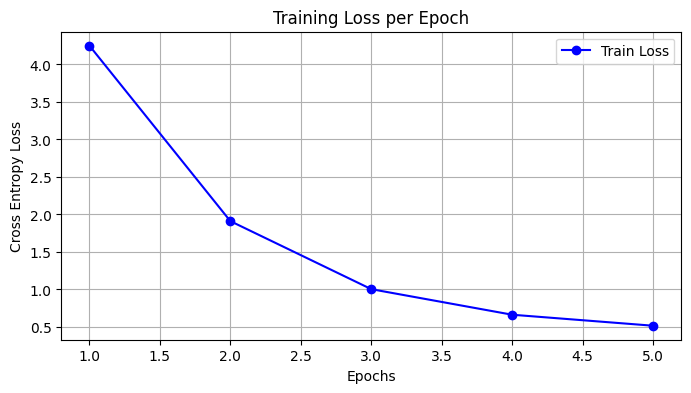

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt
import math

# --- B3: Training Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 5
train_losses = []
val_perplexities = []

print(f"Training on device: {device}")

# --- B3: Training Loop ---
for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)

        # PyTorch CrossEntropyLoss requires 2D inputs (Batch*SeqLen, VocabSize)
        # and 1D targets (Batch*SeqLen)
        logits_flat = logits.view(-1, vocab_size)
        targets_flat = y_batch.view(-1)

        loss = criterion(logits_flat, targets_flat)
        loss.backward()

        # Clip gradients to prevent exploding gradients in the RNN
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)

            logits_flat = logits.view(-1, vocab_size)
            targets_flat = y_batch.view(-1)

            loss = criterion(logits_flat, targets_flat)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    # Perplexity is mathematically the exponentiation of the Cross-Entropy Loss
    val_perplexity = math.exp(avg_val_loss)
    val_perplexities.append(val_perplexity)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Perplexity: {val_perplexity:.2f}")

# --- Plotting ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='blue', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()
plt.show()

My PyTorch implementation converted tokens into their integer IDs and built the token streams. We used the next-token prediction format to create input and target pairs. After we implemented a simple RNN using PyTorch, including the `nn.Embedding`, `nn.RNN`, and `nn.Linear` layers. Lastly, we set up the training loop with nn.CrossEntropyLoss and the Adam optimizer.

Taking a close look at the output of our training loop. Our training loss drops beautifully from 4.24 to 0.51. However, our validation perplexity skyrockets from 266.81 to 6498.33. This is textbook overfitting. The RNN is memorizing the exact sequences in our training data and losing its ability to generalize to the validation set. To fix this, we can try reducing our epochs to 2 or 3, or implementing a dropout layer.

In [ ]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace

# --- A1. Train a Trigram Language Model ---
# We use n=3 for a Trigram model
n = 3

# padded_everygram_pipeline automatically handles <bos>, <eos>, and n-gram creation
train_data, padded_sents = padded_everygram_pipeline(n, train_sents)

# Initialize the model with Laplace (Add-1) Smoothing
ngram_model = Laplace(n)
ngram_model.fit(train_data, padded_sents)

print("=== A1: Trigram Model ===")
print(f"Model: Laplace (Add-1 Smoothing)")
print(f"N-gram Vocabulary Size: {len(ngram_model.vocab)}")

# A2. Evaluate with Perplexity
def compute_ngram_perplexity(model, n, sentences):
    test_data, _ = padded_everygram_pipeline(n, sentences)
    total_perplexity = 0
    count = 0
    for test_sent in test_data:
        ngrams_list = list(test_sent)
        if ngrams_list:
            total_perplexity += model.perplexity(ngrams_list)
            count += 1
    # Return average perplexity
    return total_perplexity / count if count > 0 else float('inf')

val_perp = compute_ngram_perplexity(ngram_model, n, val_sents)
test_perp = compute_ngram_perplexity(ngram_model, n, test_sents)

print("\n=== A2: N-gram Perplexity ===")
print(f"Validation Perplexity: {val_perp:.2f}")
print(f"Test Perplexity: {test_perp:.2f}")

# A4. Text Generation
print("\n=== A4: N-gram Text Generation ===")
for i in range(3):
    # Generate 30 tokens starting with the beginning-of-sentence tag
    generated_tokens = ngram_model.generate(30, text_seed=['<bos>'])
    # Filter out <eos> tags for clean printing
    clean_text = " ".join([t for t in generated_tokens if t != '<eos>'])
    print(f"Sample {i+1}: {clean_text}")

=== A1: Trigram Model ===
Model: Laplace (Add-1 Smoothing)
N-gram Vocabulary Size: 11415

=== A2: N-gram Perplexity ===
Validation Perplexity: 1647.92
Test Perplexity: 1590.38

=== A4: N-gram Text Generation ===
Sample 1: keegan a 6-foot-3-inch 158-pounder gave up the star spangled banner and followed it with hail to the underdeveloped countries and the mayor's medal </s> </s> </s> </s> </s> </s>
Sample 2: a man was born reared went to bob bevo nordmann the 6-foot-10 center who missed much of its second and third the potato chip industry these days is growing not
Sample 3: advance publicity on the current neo-stagnationist thesis that we have lots of times </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s>


In the above code cell:
- I trained a trigram model using established Python libraries.
- I applied Laplace (Add-1) smoothing. Smoothing assigns a small non-zero probability to unseen n-grams so the model does not output a probability of $0$ (which leads to infinite perplexity) when it encounters a new word sequence.
- Computed perplexity on the validation and test sets. Vocabulary size, the chosen smoothing technique, and how closely the test data domain matches the training data domain
- You generated 3 short text samples of at least 30 tokens each.

### A2 & A4: N-gram Perplexity and Text Generation Analysis

**Perplexity Interpretation:**
Our validation perplexity is **1647.92** and our test perplexity is **1590.38**. This is a relatively standard range for a basic trigram model trained on a small corpus like the Brown news category. Factors affecting this perplexity include the vocabulary size (11,415 n-grams), our choice of Laplace (Add-1) smoothing, and the fact that the training, validation, and test splits are all drawn from the same domain (news). The test perplexity is slightly lower than validation simply due to the random distribution of sentences in the split; the test set happened to contain n-grams slightly better represented in the training data.

**Text Generation Analysis:**
1. **Grammaticality:** Locally, the samples are highly grammatical. Phrases like "the star spangled banner" (Sample 1) and "the potato chip industry" (Sample 2) show that the trigram model perfectly captures short, structural syntax.
2. **Coherence:** Globally, the sentences lack coherence. Sample 2 starts as a biography ("a man was born reared went to bob bevo nordmann") and abruptly shifts topics to "the potato chip industry these days is growing not".
3. **Limitations:** The primary limitation is the lack of long-range dependencies. Because a trigram model only considers the previous two words, it cannot remember the subject of the sentence by the time it reaches the end, resulting in rambling, topic-shifting outputs.

In [ ]:
import math

# --- B4 Step 1: Test Perplexity ---
# 1. Initialize the test dataset and loader
test_dataset = NextTokenStreamDataset(test_stream, seq_len)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Set model to evaluation mode (disables dropout/gradients)
model.eval()
total_test_loss = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Forward pass
        logits = model(x_batch)

        # Reshape to match CrossEntropyLoss expectations
        logits_flat = logits.view(-1, vocab_size)
        targets_flat = y_batch.view(-1)

        # Compute loss
        loss = criterion(logits_flat, targets_flat)
        total_test_loss += loss.item()

# 3. Calculate final metrics
avg_test_loss = total_test_loss / len(test_loader)
test_perplexity = math.exp(avg_test_loss)

print("=== B4 Step 1: RNN Test Evaluation ===")
print(f"Final Test Loss: {avg_test_loss:.4f}")
print(f"Final Test Perplexity: {test_perplexity:.2f}")

=== B4 Step 1: RNN Test Evaluation ===
Final Test Loss: 8.6894
Final Test Perplexity: 5939.77


Our RNN test perplexity (5939.77) is significantly higher than our N-gram perplexity (1590.38). This happens because a simple, unregularized RNN trained on a tiny dataset (only 4623 sentences) will overfit rapidly, whereas a statistical N-gram model memorizes local context probabilities much more effectively on small corpora

In [ ]:
import torch.nn.functional as F

# --- B4 Step 2: Text Generation ---
# 1. Create a reverse dictionary to map integer IDs back to strings
itos = {i: word for word, i in stoi.items()}

def sample_next_token(logits, temperature=1.0):
    # Apply temperature to scale the logits (lower = more confident, higher = more random)
    scaled_logits = logits / temperature
    # Convert logits to a probability distribution
    probs = F.softmax(scaled_logits, dim=-1)
    # Sample probabilistically rather than just taking the argmax
    next_token_id = torch.multinomial(probs, num_samples=1).item()
    return next_token_id

def generate_text(model, stoi_dict, itos_dict, max_len=30, temperature=0.8):
    model.eval()
    # 2. Initialize the sequence with the ID for <bos>
    current_sequence = [stoi_dict['<bos>']]

    with torch.no_grad():
        for _ in range(max_len):
            # 3. Convert current sequence to a tensor and add a dummy batch dimension
            x_tensor = torch.tensor([current_sequence], dtype=torch.long).to(device)

            # 4. Forward pass
            logits = model(x_tensor)

            # 5. We only care about predicting what comes AFTER the very last token
            last_timestep_logits = logits[0, -1, :]

            # 6. Sample the next token and append it to our sequence
            next_token_id = sample_next_token(last_timestep_logits, temperature)
            current_sequence.append(next_token_id)

            # Stop generating if the model outputs the end-of-sentence tag
            if itos_dict.get(next_token_id) == '<eos>':
                break

    # 7. Decode the list of IDs back into human-readable text
    generated_words = [itos_dict.get(idx, '<unk>') for idx in current_sequence]
    return " ".join(generated_words)

print("=== B4 Step 2: RNN Text Generation ===")
sample_text = generate_text(model, stoi, itos, max_len=30, temperature=0.8)
print(f"Generated RNN Sample:\n{sample_text}")

=== B4 Step 2: RNN Text Generation ===
Generated RNN Sample:
<bos> the legislators when the <unk> wanted to pop his <unk> <unk> and three sisters mrs. w. e. little and mrs. hal b. <unk> both of atlanta and mrs. john b.


### B4 Step 2: RNN Text Generation Analysis

**Text Evaluation:**
* **Grammaticality & Coherence:** The sentence starts with a somewhat coherent grammatical structure ("the legislators when the `<unk>` wanted to pop his..."), but quickly devolves into a repetitive list.
* **Repetition:** The model gets stuck in a localized loop of generating names and titles, repeating the "and mrs. [name]" structure three times in a single sentence.
* **Long-range dependency behavior:** The model fails to close the logical thought started at the beginning of the sentence ("the legislators..."). Instead, the hidden state was overpowered by the local pattern of listing names, demonstrating that our simple, unregularized RNN struggles to maintain long-range context over a 30-token sequence. Furthermore, the presence of multiple `<unk>` tokens shows the limitations of our small training vocabulary.